<a href="https://colab.research.google.com/github/PauloFernandes26/AD2526/blob/main/AD2526_LabAssignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Setup, Version check and Common imports

# Python ≥ 3.7 is required
import sys
assert sys.version_info >= (3, 7)


# TensorFlow ≥ 2.8 is required
import tensorflow as tf
from packaging import version

assert version.parse(tf.__version__) >= version.parse("2.8.0")

# Common imports
import numpy as np
import os
import pandas as pd

from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

print('Python version: ', sys.version_info)
print('TF version: ', tf.__version__)
print('Keras version: ', keras.__version__)
print('GPU is', 'available' if tf.config.list_physical_devices('GPU') else 'NOT AVAILABLE')

Python version:  sys.version_info(major=3, minor=12, micro=12, releaselevel='final', serial=0)
TF version:  2.19.0
Keras version:  3.13.2
GPU is available


**Cats and Dogs Dataset**

**1. Dataset Downloading**

In [2]:
# Download the Dataset and create a directory PetImages with two folders: Cat and Dog
# https://www.kaggle.com/datasets/tongpython/cat-and-dog
# https://www.microsoft.com/en-us/download/details.aspx?id=54765
# Each of the folders contains images from one class

!curl -O https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip

!unzip -q kagglecatsanddogs_5340.zip

!rm kagglecatsanddogs_5340.zip


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  786M  100  786M    0     0  92.0M      0  0:00:08  0:00:08 --:--:-- 77.0M


In [3]:
# Some images are corrupted, so they have to be removed

import os

num_skipped = 0
for folder_name in ("Cat", "Dog"):
    folder_path = os.path.join("PetImages", folder_name)
    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        try:
            fobj = open(fpath, "rb")
            is_jfif = b"JFIF" in fobj.peek(10)
        finally:
            fobj.close()

        if not is_jfif:
            num_skipped += 1
            # Delete corrupted image
            os.remove(fpath)

print(f"Deleted {num_skipped} images.")

Deleted 1590 images.


In [4]:

cat_dir = 'PetImages/Cat'
dog_dir = 'PetImages/Dog'

num_cats = len(os.listdir(cat_dir))
num_dogs = len(os.listdir(dog_dir))

print('Cat images:', num_cats)
print('Dog images: ', num_dogs)

Cat images: 11742
Dog images:  11670


**2. Dataset Preprocessing**

Found 23410 files belonging to 2 classes.
Using 18728 files for training.
Found 23410 files belonging to 2 classes.
Using 4682 files for validation.
Classes: ['Cat', 'Dog']
Train batches: 586
Validation batches: 73
Test batches: 74


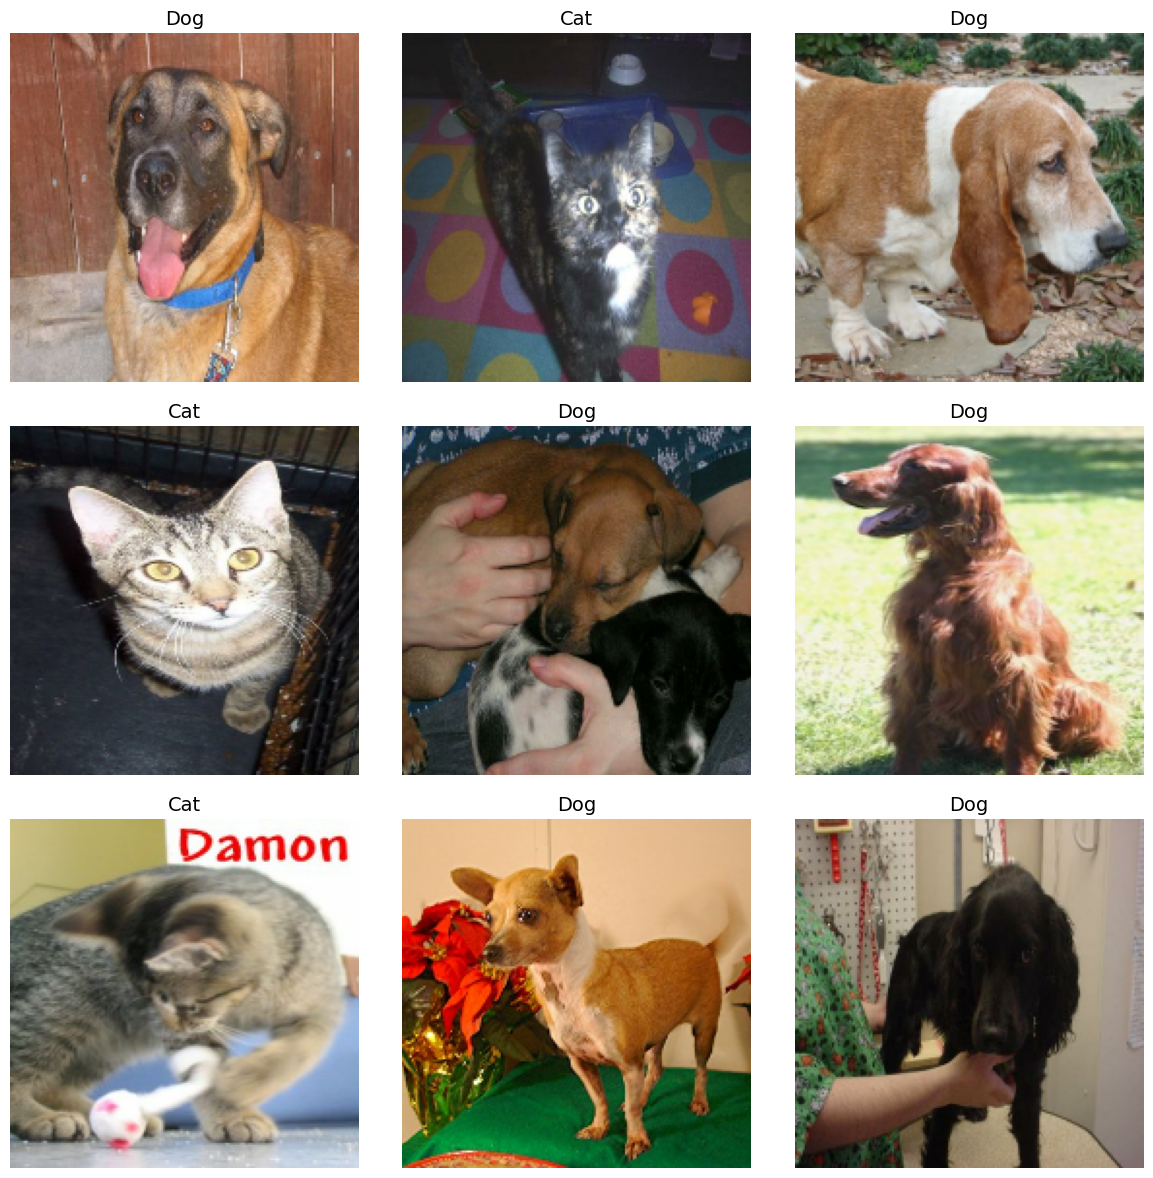

In [5]:
# Code goes here

# DATA PREPROCESSING

# We will:
# 1. Resize all images to a fixed size
# 2. Split the dataset into train / validation / test
# 3. Normalize pixel values to [0,1] inside the model
# 4. Use batching + prefetching for efficiency

BATCH_SIZE = 32
IMG_SIZE = (180, 180)
SEED = 42

dataset_dir = "PetImages"

# Full training dataset (later we split validation into validation + test)
train_val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

val_test_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

# Split the 20% validation subset into validation (10%) and test (10%)
val_batches = tf.data.experimental.cardinality(val_test_ds)
val_ds = val_test_ds.take(val_batches // 2)
test_ds = val_test_ds.skip(val_batches // 2)

# Improve pipeline performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_val_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

# Check class names
class_names = train_val_ds.class_names
print("Classes:", class_names)

# Check dataset sizes
print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

# Visualize a few examples
plt.figure(figsize=(12, 12))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i].numpy()[0])])
        plt.axis("off")
plt.tight_layout()
plt.show()


**3. Creating, Training and Evaluating a Baseline CNN**

In [6]:
# Baseline CNN

# It must comply with the following constraints:
#   1. Use Keras Functional API
#   2. Maximum of 5 million parameters
#   3. Without transfer learning
#   4. Without data augmentation
#   5. Without regularization or other explicit techniques to fight overfitting

keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

# Code goes here

inputs = keras.Input(shape=(180, 180, 3))

# Rescaling only (normalization is necessary preprocessing, not augmentation)
x = layers.Rescaling(1./255)(inputs)

x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D()(x)

x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

baseline_cnn = keras.Model(inputs=inputs, outputs=outputs, name="baseline_cnn")

baseline_cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

baseline_cnn.summary()

history_baseline = baseline_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

baseline_test_loss, baseline_test_acc = baseline_cnn.evaluate(test_ds)
print(f"Baseline Test Loss: {baseline_test_loss:.4f}")
print(f"Baseline Test Accuracy: {baseline_test_acc:.4f}")


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 22, 22, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 11, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 15488)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,982,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,223,553 (8.48 MB)

 Trainable params: 2,223,553 (8.48 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
586/586 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.6272 - loss: 0.6331 - val_accuracy: 0.7581 - val_loss: 0.5155
Epoch 2/20
586/586 ━━━━━━━━━━━━━━━━━━━━ 30s 51ms/step - accuracy: 0.7454 - loss: 0.5129 - val_accuracy: 0.7834 - val_loss: 0.4662
Epoch 3/20
586/586 ━━━━━━━━━━━━━━━━━━━━ 28s 48ms/step - accuracy: 0.7951 - loss: 0.4367 - val_accuracy: 0.8373 - val_loss: 0.3680
Epoch 4/20
586/586 ━━━━━━━━━━━━━━━━━━━━ 28s 49ms/step - accuracy: 0.8382 - loss: 0.3649 - val_accuracy: 0.8527 - val_loss: 0.3389
Epoch 5/20
586/586 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.8712 - loss: 0.3020 - val_accuracy: 0.8596 - val_loss: 0.3335
Epoch 6/20
586/586 ━━━━━━━━━━━━━━━━━━━━ 28s 48ms/step - accuracy: 0.9027 - loss: 0.2331 - val_accuracy: 0.8716 - val_loss: 0.3044
Epoch 7/20
586/586 ━━━━━━━━━━━━━━━━━━━━ 30s 51ms/step - accuracy: 0.9262 - loss: 0.1802 - val_accuracy: 0.8729 - val_loss: 0.3199
Epoch 8/20
586/586 ━━━━━━━━━━━━━━━━━━━━ 38s 46ms/step - accuracy: 0.9490 - loss: 0.1311 - 

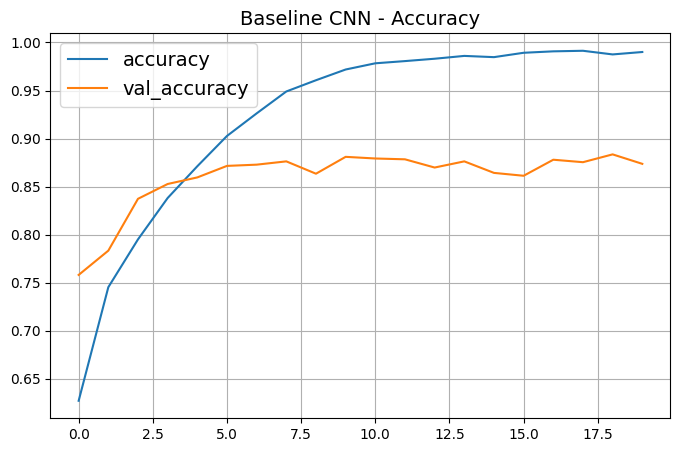

In [8]:
x = pd.DataFrame(history_baseline.history, columns=['accuracy', 'val_accuracy'])
x.plot(figsize=(8, 5))
plt.title("Baseline CNN - Accuracy")
plt.grid(True)
plt.show()

**4. Creating, Training and Evaluating an Enhanced CNN**


Model: "enhanced_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 180, 180, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 180, 180, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 90, 90, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 90, 90, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 45, 45, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 45, 45, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 22, 22, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 22, 22, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 22, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 11, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 422,881 (1.61 MB)

 Trainable params: 421,921 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/20
586/586 ━━━━━━━━━━━━━━━━━━━━ 65s 99ms/step - accuracy: 0.6284 - loss: 0.6482 - val_accuracy: 0.5775 - val_loss: 0.6792
Epoch 2/20
586/586 ━━━━━━━━━━━━━━━━━━━━ 76s 96ms/step - accuracy: 0.6826 - loss: 0.5930 - val_accuracy: 0.6485 - val_loss: 0.6371
Epoch 3/20
586/586 ━━━━━━━━━━━━━━━━━━━━ 55s 94ms/step - accuracy: 0.7187 - loss: 0.5580 - val_accuracy: 0.6648 - val_loss: 0.5891
Epoch 4/20
586/586 ━━━━━━━━━━━━━━━━━━━━ 58s 99ms/step - accuracy: 0.7365 - loss: 0.5331 - val_accuracy: 0.6464 - val_loss: 0.7018
Epoch 5/20
586/586 ━━━━━━━━━━━━━━━━━━━━ 82s 100ms/step - accuracy: 0.7506 - loss: 0.5125 - val_accuracy: 0.6575 - val_loss: 0.7166
Epoch 6/20
586/586 ━━━━━━━━━━━━━━━━━━━━ 56s 96ms/step - accuracy: 0.7675 - loss: 0.4915 - val_accuracy: 0.7098 - val_loss: 0.5754
Epoch 7/20
586/586 ━━━━━━━━━━━━━━━━━━━━ 58s 99ms/step - accuracy: 0.7804 - loss: 0.4673 - val_accuracy: 0.7008 - val_loss: 0.5941
Epoch 8/20
586/586 ━━━━━━━━━━━━━━━━━━━━ 57s 97ms/step - accuracy: 0.7994 - loss: 0.4383 -

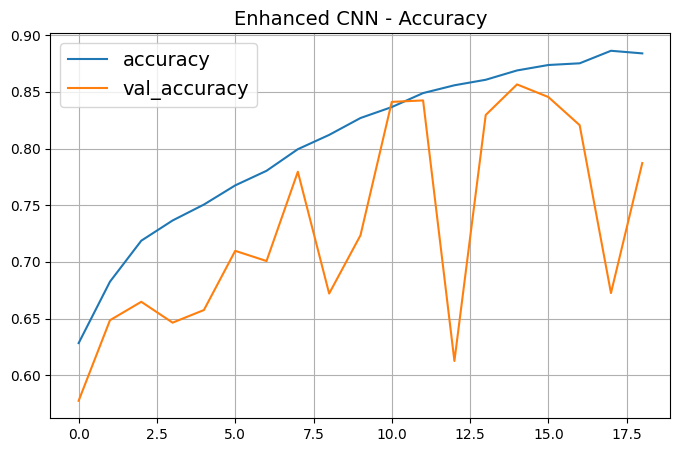

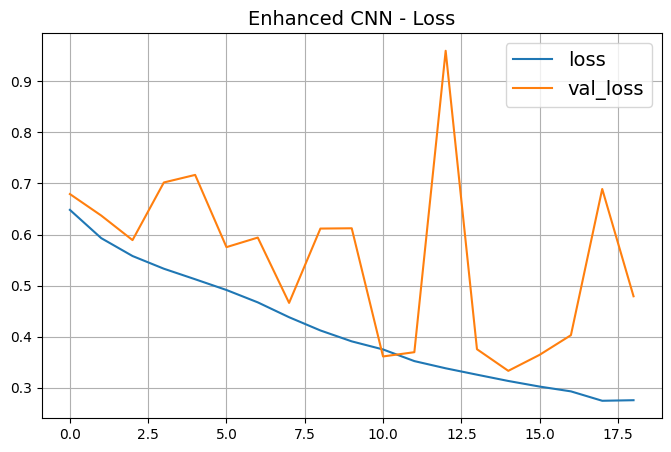

In [9]:
# Enhanced CNN

# It must comply with the following constraints:
#   1. Use Keras Functional API
#   2. Maximum of 5 million parameters
#   3. Without transfer learning

keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

# Code goes here


data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.05, 0.05)
])

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

inputs = keras.Input(shape=(180, 180, 3))

x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)

x = layers.Conv2D(32, (3,3), padding='same', use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D(pool_size=(2,2))(x)

x = layers.Conv2D(64, (3,3), padding='same', use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D(pool_size=(2,2))(x)

x = layers.Conv2D(128, (3,3), padding='same', use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D(pool_size=(2,2))(x)

x = layers.Conv2D(256, (3,3), padding='same', use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D(pool_size=(2,2))(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

enhanced_cnn = keras.Model(inputs=inputs, outputs=outputs, name="enhanced_cnn")

enhanced_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

enhanced_cnn.summary()

history_enhanced = enhanced_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping]
)

enhanced_test_loss, enhanced_test_acc = enhanced_cnn.evaluate(test_ds)

print(f"Enhanced Test Loss: {enhanced_test_loss:.4f}")
print(f"Enhanced Test Accuracy: {enhanced_test_acc:.4f}")

x = pd.DataFrame(history_enhanced.history, columns=['accuracy', 'val_accuracy'])
x.plot(figsize=(8, 5))
plt.title("Enhanced CNN - Accuracy")
plt.grid(True)
plt.show()

x = pd.DataFrame(history_enhanced.history, columns=['loss', 'val_loss'])
x.plot(figsize=(8, 5))
plt.title("Enhanced CNN - Loss")
plt.grid(True)
plt.show()
